# **Lab 5 Mega Test — Set 2**
**Topics:** NumPy operations, Pandas wrangling, Visualization, Linear/Logistic Regression
**Time:** 60 min | **Total Marks:** 100
Dataset (provided): **health_metrics.csv**
Goal: Analyze patient data to predict calories_burned (numeric) or stress_category (binary: 0/1) based on biometric inputs.


### **Part A — Data Wrangling & Feature Engineering (40 marks)**
1. **Anomaly Detection with NumPy (15 marks):**
   - Load the dataset and identify `Blood_Pressure_Systolic` and `Blood_Pressure_Diastolic` columns.
   - Use NumPy to identify 'impossible' records where Systolic pressure is lower than or equal to Diastolic pressure.
   - Use NumPy to set these values to NaN and fill missing values using the backward fill method.

In [2]:
# Task 1: Anomaly Detection with NumPy
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('health_metrics.csv')

# Identify impossible records: Systolic <= Diastolic
impossible_records = df[df['Blood_Pressure_Systolic'] <= df['Blood_Pressure_Diastolic']]
impossible_records

# Set impossible records to NaN
df.loc[df['Blood_Pressure_Systolic'] <= df['Blood_Pressure_Diastolic'], ['Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic']] = np.nan

# Fill NaN values using backward fill
df.fillna(method='bfill', inplace=True)
df.head()  # Display updated data

C:\Users\HP\AppData\Local\Temp\ipykernel_10872\4011312661.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


,age,gender,activity_level,heart_rate,body_temperature,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,session_timestamp,calories_burned,stress_category
0,56,Female,Medium,59,37.19,112.0,70.0,2026-02-26 17:49:00,106.74,0
1,46,Female,Medium,111,37.09,156.0,79.0,2026-02-11 14:09:00,242.10,1
2,32,Male,High,71,36.66,131.0,75.0,2026-01-19 17:47:00,126.76,0
3,60,Male,Medium,101,36.63,119.0,63.0,2026-02-24 15:54:00,265.06,1
4,25,Female,Low,77,36.78,142.0,65.0,2026-02-10 12:28:00,34.88,0


2. **Pivot Table Analysis & Logic (15 marks):**
   - Create a Pivot Table to show the average `heart_rate` for each combination of `gender` and `activity_level`.
   - Identify the group with the highest resting heart rate.
   - Filter for patients with `heart_rate` above the 95th percentile.

In [3]:
# Task 2: Pivot Table Analysis & Logic
# Create a pivot table to show average heart_rate for each gender + activity level combination
pivot_table = df.pivot_table(values='heart_rate', index=['gender', 'activity_level'], aggfunc='mean')
pivot_table

# Identify the group with the highest heart_rate
highest_heart_rate_group = pivot_table.idxmax()  # This will give the gender and activity level combination
highest_heart_rate_group

# Filter for patients with heart_rate > 95th percentile
heart_rate_95th = np.percentile(df['heart_rate'], 95)
high_heart_rate_patients = df[df['heart_rate'] > heart_rate_95th]
high_heart_rate_patients.head()  # Display patients

,age,gender,activity_level,heart_rate,body_temperature,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,session_timestamp,calories_burned,stress_category
7,36,Female,Medium,129,36.90,109.0,62.0,2026-02-14 12:26:00,165.74,1
26,39,Female,Low,128,37.15,148.0,96.0,2026-03-06 08:13:00,131.06,1
34,64,Male,Medium,129,36.97,141.0,92.0,2026-01-09 12:49:00,209.67,1
37,54,Female,Medium,129,36.36,114.0,89.0,2026-01-17 02:11:00,283.38,1
67,35,Male,Low,127,37.25,134.0,95.0,2026-03-07 08:08:00,89.60,1


3. **Time-Feature Extraction (10 marks):**
   - Convert `session_timestamp` to a datetime object and extract `hour_of_day`.
   - Drop the original `session_timestamp` column.

In [4]:
# Task 3: Time-Feature Extraction
df['session_timestamp'] = pd.to_datetime(df['session_timestamp'])

# Extract hour_of_day from session_timestamp
df['hour_of_day'] = df['session_timestamp'].dt.hour

# Drop the original session_timestamp column
df.drop(columns=['session_timestamp'], inplace=True)
df.head()  # Display updated data

,age,gender,activity_level,heart_rate,body_temperature,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,calories_burned,stress_category,hour_of_day
0,56,Female,Medium,59,37.19,112.0,70.0,106.74,0,17
1,46,Female,Medium,111,37.09,156.0,79.0,242.10,1,14
2,32,Male,High,71,36.66,131.0,75.0,126.76,0,17
3,60,Male,Medium,101,36.63,119.0,63.0,265.06,1,15
4,25,Female,Low,77,36.78,142.0,65.0,34.88,0,12


### **Part B — Distribution & Relationship Analysis (25 marks)**
4. **Categorical Distribution & Outliers (12 marks):**
   - Create a Box Plot comparing `calories_burned` across different `activity_level` categories.
   - Add a horizontal line for the mean of `calories_burned`.
   - Analyze outliers in the 'High Activity' box plot.

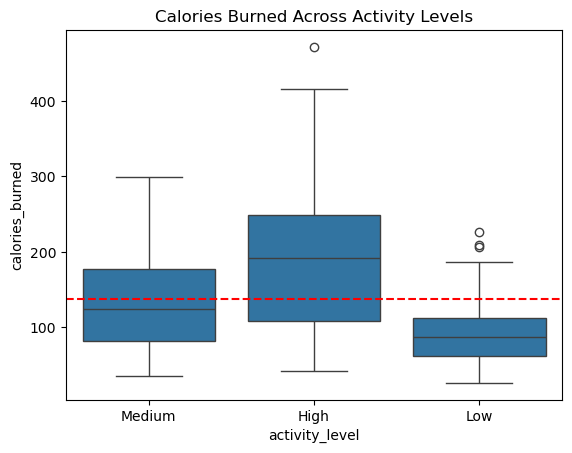

In [6]:
# Task 4: Categorical Distribution & Outliers
import seaborn as sns
import matplotlib.pyplot as plt

# Create a BoxPlot comparing calories_burned across activity_level categories
sns.boxplot(x='activity_level', y='calories_burned', data=df)
plt.axhline(y=df['calories_burned'].mean(), color='r', linestyle='--')  # Add mean line
plt.title('Calories Burned Across Activity Levels')
plt.show()

5. **Density & Relationship Viz (13 marks):**
   - Plot a Kernel Density Estimate (KDE) for `body_temperature`.
   - Create a JointPlot between `age` and `calories_burned`.
   - Label the axes correctly.

C:\Users\HP\AppData\Local\Temp\ipykernel_10872\3560414607.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['body_temperature'], shade=True)


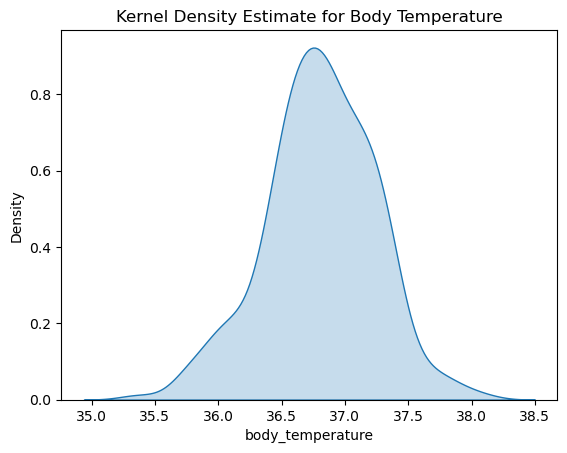

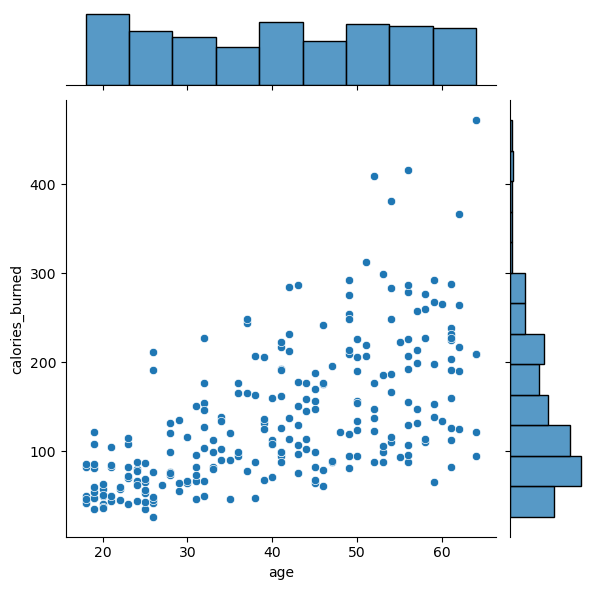

In [7]:
# Task 5: Density & Relationship Viz
sns.kdeplot(df['body_temperature'], shade=True)
plt.title('Kernel Density Estimate for Body Temperature')
plt.show()

# Create a JointPlot between age and calories_burned
sns.jointplot(x='age', y='calories_burned', data=df, kind='scatter')
plt.show()

### **Part C — Machine Learning Model (35 marks)**
6. **Feature Selection & Standardization (12 marks):**
   - Apply Min-Max Scaling to the features (`age`, `heart_rate`, `hour_of_day`) and target (`calories_burned`).

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Define the features and target
features = ['age', 'heart_rate', 'hour_of_day']
target = 'calories_burned'

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling to the features and target
df[features] = scaler.fit_transform(df[features])
df[target] = scaler.fit_transform(df[[target]])

df.head()  # Display scaled data

,age,gender,activity_level,heart_rate,body_temperature,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,calories_burned,stress_category,hour_of_day
0,0.826087,Female,Medium,0.054054,37.19,112.0,70.0,0.180991,0,0.739130
1,0.608696,Female,Medium,0.756757,37.09,156.0,79.0,0.484421,1,0.608696
2,0.304348,Male,High,0.216216,36.66,131.0,75.0,0.225869,0,0.739130
3,0.913043,Male,Medium,0.621622,36.63,119.0,63.0,0.535889,1,0.652174
4,0.152174,Female,Low,0.297297,36.78,142.0,65.0,0.019906,0,0.521739


7. **Linear Regression Training & Interpretation (13 marks):**
   - Split the data into training (80%) and testing (20%) sets.
   - Train a Linear Regression model and display coefficients.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data into training (80%) and testing (20%) sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Display the coefficients
coefficients = model.coef_
intercept = model.intercept_
coefficients, intercept

(array([ 0.35123506,  0.22405911, -0.02437056]),
 np.float64(-0.02164666249940128))

8. **Evaluation & Regression Logic (10 marks):**
   - Discuss the use of Linear Regression for predicting `calories_burned` and suggest a better model.

In [11]:
# Evaluate the model using Mean Squared Error (MSE) or R^2 score
from sklearn.metrics import mean_squared_error, r2_score

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate the Mean Squared Error (MSE) and R^2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2  # Display MSE and R^2 score

(0.015662219975483897, 0.5213458317634505)

### Discussion:

- **Linear Regression for `calories_burned` prediction**: Linear regression may not perform well as `calories_burned` likely has non-linear relationships with the features. Models like **Random Forest** or **Gradient Boosting** would perform better, as they can capture non-linear patterns and feature interactions.